In [ ]:
# ==========================================
# Question 1: Sinc Pulses
# Roll Number: 226ec003 -> xy = 03
# ==========================================
import pandas as pd

Rb = 3.0  # Bit rate in Mbps (xy = 03)

# 16-QAM (4 bits/symbol) & QPSK (2 bits/symbol)
k_16qam = 4
k_qpsk = 2

Rs_16qam = Rb / k_16qam  # 0.75 MBaud
Rs_qpsk = Rb / k_qpsk    # 1.50 MBaud

# For sinc pulses, required passband bandwidth is equal to the symbol rate
bw_16qam = Rs_16qam
bw_qpsk = Rs_qpsk

# Display the required table
df_q1 = pd.DataFrame({
    'Bandwidth required': ['Gamma = 0.99', 'Gamma = 0.90'],
    '16 QAM': [f'{bw_16qam:.4f} MHz', f'{bw_16qam:.4f} MHz'],
    'QPSK': [f'{bw_qpsk:.4f} MHz', f'{bw_qpsk:.4f} MHz']
})

print("Question 1 Result Table:")
display(df_q1)

Question 1 Result Table:


,Bandwidth required,16 QAM,QPSK
0,Gamma = 0.99,0.7500 MHz,1.5000 MHz
1,Gamma = 0.90,0.7500 MHz,1.5000 MHz


In [ ]:
# ==========================================
# Question 2: Raised Cosine Pulse Filter (beta = 0.5)
# Roll Number: 226ec003 -> xy = 03
# ==========================================
import pandas as pd

Rb = 3.0  # Bit rate in Mbps
beta = 0.5

Rs_16qam = Rb / 4  # 0.75 MBaud
Rs_qpsk = Rb / 2   # 1.50 MBaud

# Required passband bandwidth: B = Rs * (1 + beta)
bw_rc_16qam = Rs_16qam * (1 + beta)
bw_rc_qpsk = Rs_qpsk * (1 + beta)

# Display the required table
df_q2 = pd.DataFrame({
    'Bandwidth required': ['Gamma = 0.99', 'Gamma = 0.90'],
    '16 QAM': [f'{bw_rc_16qam:.4f} MHz', f'{bw_rc_16qam:.4f} MHz'],
    'QPSK': [f'{bw_rc_qpsk:.4f} MHz', f'{bw_rc_qpsk:.4f} MHz']
})

print("Question 2 Result Table (beta = 0.5):")
display(df_q2)

Question 2 Result Table (beta = 0.5):


,Bandwidth required,16 QAM,QPSK
0,Gamma = 0.99,1.1250 MHz,2.2500 MHz
1,Gamma = 0.90,1.1250 MHz,2.2500 MHz


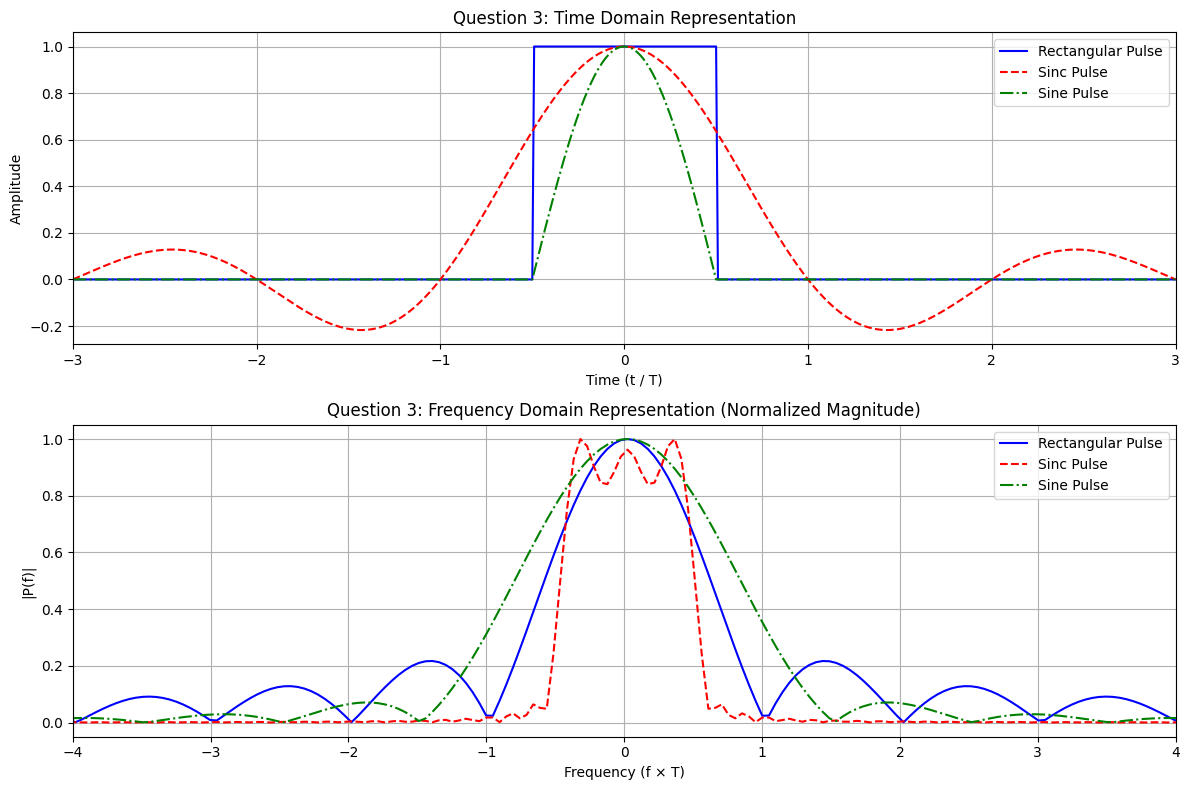

In [ ]:
# =============================================================
# Question 3: Time and Frequency Domain Representation
# (a) Rectangular pulse, (b) Sinc pulse, (c) Sine pulse
# =============================================================
import numpy as np
import matplotlib.pyplot as plt

T = 1.0         # Normalized symbol duration
Fs = 100.0      # Sampling frequency
t = np.arange(-3*T, 3*T + 1/Fs, 1/Fs)
N = 2048
f = np.linspace(-Fs/2, Fs/2, N)

# (a) Rectangular Pulse
p_rect = np.where(np.abs(t) <= T/2, 1.0, 0.0)
P_rect = np.fft.fftshift(np.fft.fft(p_rect, N)) / Fs

# (b) Sinc Pulse
p_sinc = np.sinc(t / T)
P_sinc = np.fft.fftshift(np.fft.fft(p_sinc, N)) / Fs

# (c) Sine Pulse (Half-sine shaping pulse)
p_sine = np.zeros_like(t)
idx_sine = np.abs(t) <= T/2
p_sine[idx_sine] = np.cos(np.pi * t[idx_sine] / T)
P_sine = np.fft.fftshift(np.fft.fft(p_sine, N)) / Fs

# Plotting
plt.figure(figsize=(12, 8))

# Time Domain Subplot
plt.subplot(2, 1, 1)
plt.plot(t, p_rect, label='Rectangular Pulse', color='b', linewidth=1.5)
plt.plot(t, p_sinc, label='Sinc Pulse', color='r', linestyle='--', linewidth=1.5)
plt.plot(t, p_sine, label='Sine Pulse', color='g', linestyle='-.', linewidth=1.5)
plt.title('Question 3: Time Domain Representation')
plt.xlabel('Time (t / T)')
plt.ylabel('Amplitude')
plt.xlim([-3, 3])
plt.grid(True)
plt.legend()

# Frequency Domain Subplot
plt.subplot(2, 1, 2)
plt.plot(f, np.abs(P_rect) / np.max(np.abs(P_rect)), label='Rectangular Pulse', color='b', linewidth=1.5)
plt.plot(f, np.abs(P_sinc) / np.max(np.abs(P_sinc)), label='Sinc Pulse', color='r', linestyle='--', linewidth=1.5)
plt.plot(f, np.abs(P_sine) / np.max(np.abs(P_sine)), label='Sine Pulse', color='g', linestyle='-.', linewidth=1.5)
plt.title('Question 3: Frequency Domain Representation (Normalized Magnitude)')
plt.xlabel('Frequency (f × T)')
plt.ylabel('|P(f)|')
plt.xlim([-4, 4])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

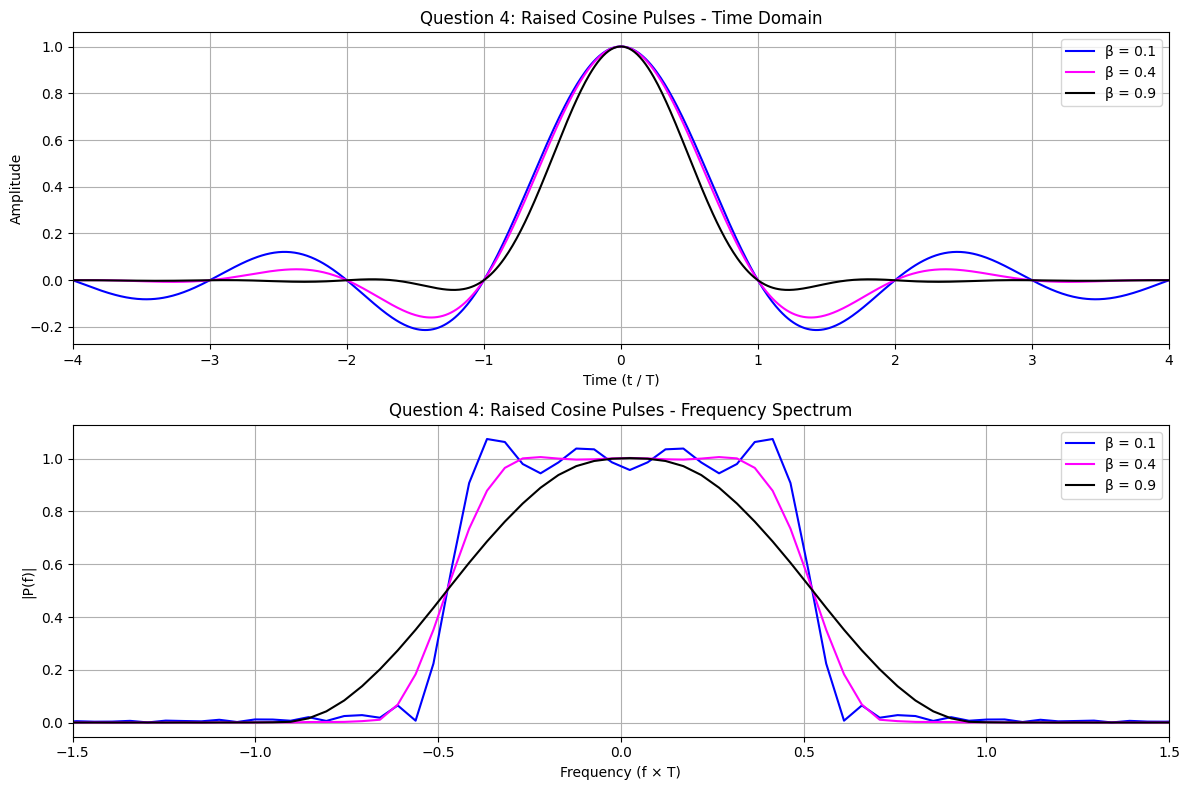

In [ ]:
# =============================================================
# Question 4: Raised Cosine Pulse Filter with beta = 0.1, 0.4, 0.9
# =============================================================
import numpy as np
import matplotlib.pyplot as plt

T = 1.0
Fs = 100.0
t = np.arange(-4*T, 4*T + 1/Fs, 1/Fs)
N = 2048
f = np.linspace(-Fs/2, Fs/2, N)

betas = [0.1, 0.4, 0.9]
colors = ['blue', 'magenta', 'black']

plt.figure(figsize=(12, 8))

for b, c in zip(betas, colors):
    # Time domain analytical formula
    denom = 1 - (2 * b * t / T)**2
    p_rc = np.sinc(t / T) * np.cos(np.pi * b * t / T) / denom

    # Handle singularity when denominator is 0
    sing_idx = np.isclose(np.abs(t), T / (2 * b), atol=1e-4)
    p_rc[sing_idx] = (np.pi / 4) * np.sinc(1 / (2 * b))

    # Frequency domain spectrum via FFT
    P_rc = np.fft.fftshift(np.fft.fft(p_rc, N)) / Fs

    # Time Domain Plot
    plt.subplot(2, 1, 1)
    plt.plot(t, p_rc, label=f'β = {b}', color=c, linewidth=1.5)

    # Frequency Domain Plot
    plt.subplot(2, 1, 2)
    plt.plot(f, np.abs(P_rc), label=f'β = {b}', color=c, linewidth=1.5)

plt.subplot(2, 1, 1)
plt.title('Question 4: Raised Cosine Pulses - Time Domain')
plt.xlabel('Time (t / T)')
plt.ylabel('Amplitude')
plt.xlim([-4, 4])
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.title('Question 4: Raised Cosine Pulses - Frequency Spectrum')
plt.xlabel('Frequency (f × T)')
plt.ylabel('|P(f)|')
plt.xlim([-1.5, 1.5])
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Enter the last two digits of your roll number (for example, 07): 03

Bit rate = 3 Mbps
16-QAM symbol rate = 0.75 Msymbol/s
QPSK symbol rate   = 1.5 Msymbol/s
Assumption: gamma is the fraction of total signal power.
Q2 uses a normal raised-cosine transmit pulse.
All values below are MHz.
RF width = 2 x one-sided baseband width.

Q1: Sinc
Gamma    16-QAM RF     QPSK RF     16-QAM BB     QPSK BB
0.99       0.742500    1.485000     0.371250    0.742500
0.90       0.675000    1.350000     0.337500    0.675000
100% full-support RF width: 16-QAM = 0.750000 MHz; QPSK = 1.500000 MHz.

Q2: Raised cosine, beta=0.5
Gamma    16-QAM RF     QPSK RF     16-QAM BB     QPSK BB
0.99       0.835541    1.671083     0.417771    0.835541
0.90       0.635168    1.270337     0.317584    0.635168
100% full-support RF width: 16-QAM = 1.125000 MHz; QPSK = 2.250000 MHz.

Four figures and the bandwidth tables are saved in: /content/pulse_shaping_reference_outputs
Q3 sine: 5 Hz over 1 second. Sinc window: [-20,20]. 

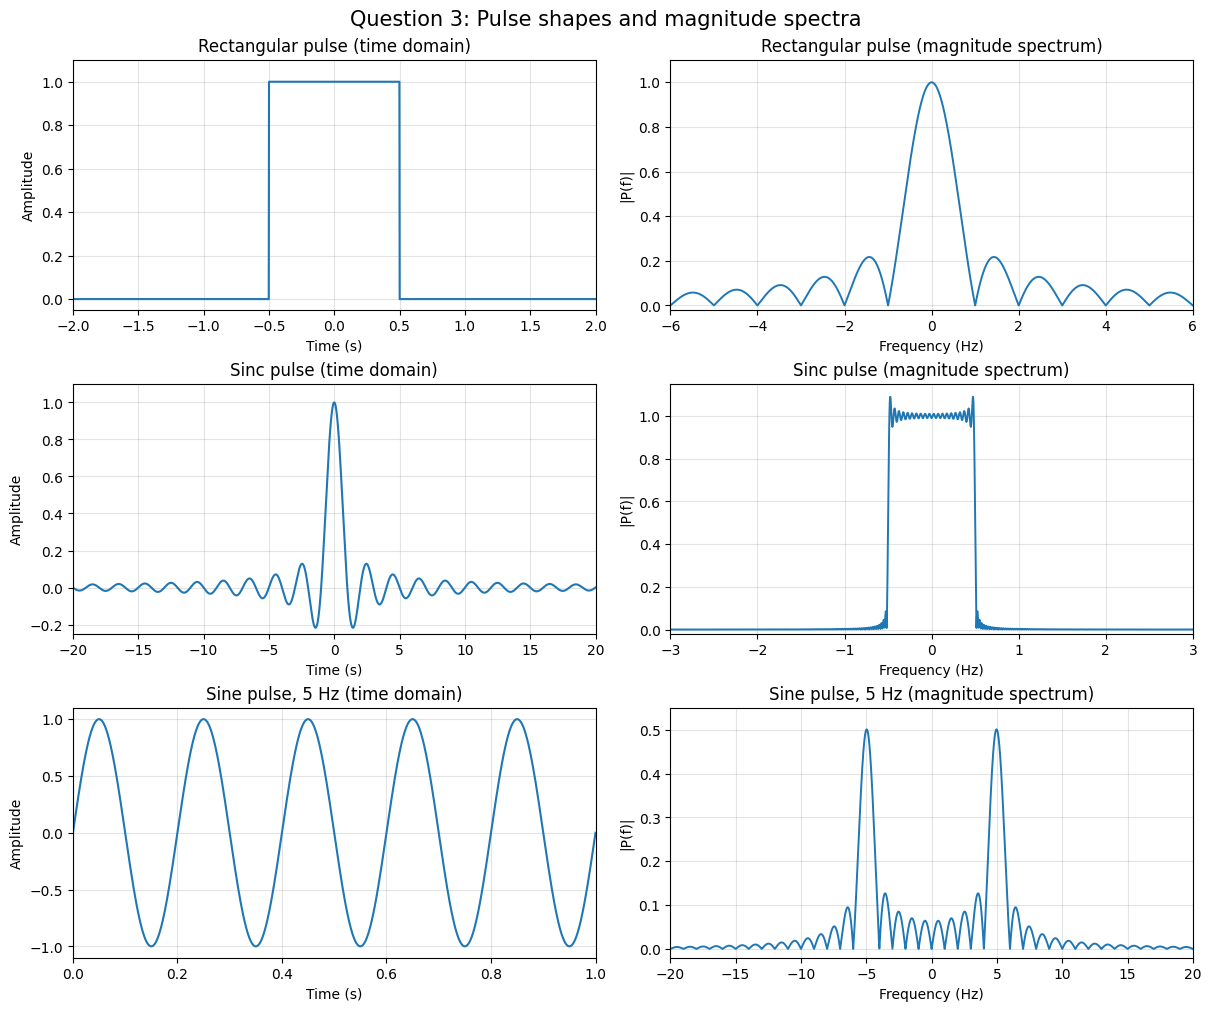

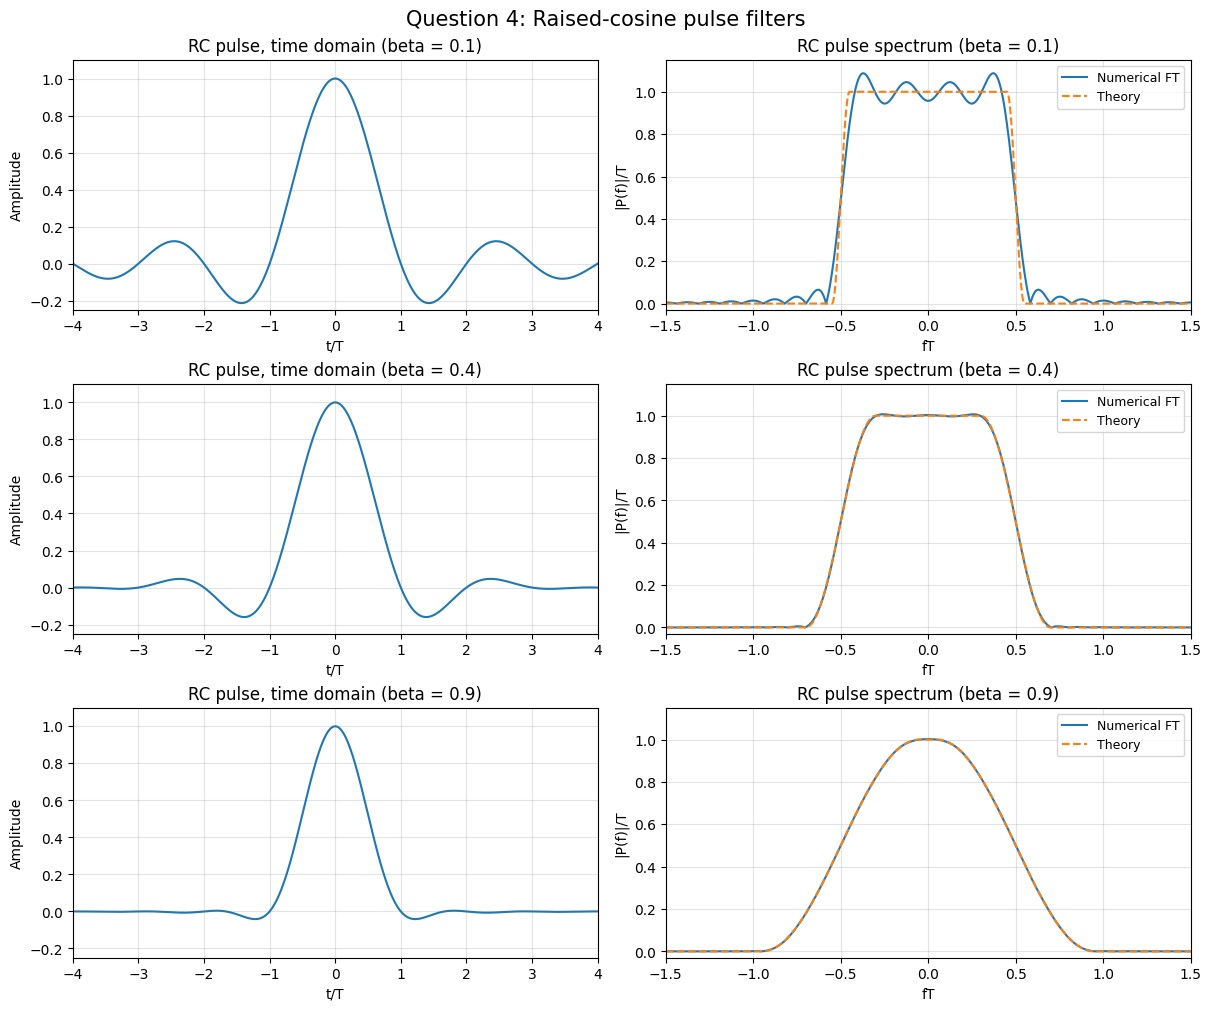

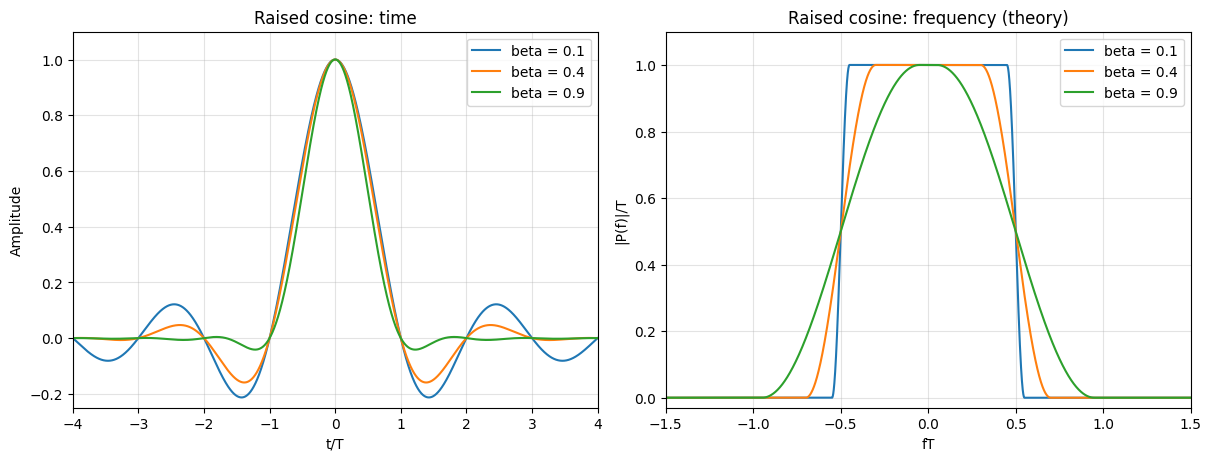

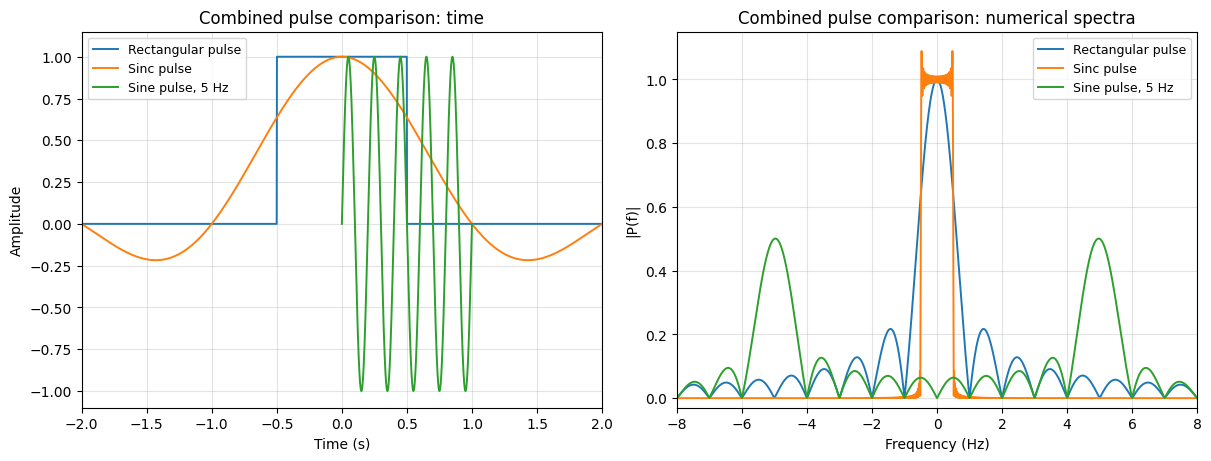

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import brentq

# ---------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------
# Q1/Q2: gamma = fraction of total signal power.
# Q2 uses a normal raised-cosine transmit pulse.
#
# Q3 reference:
# Rectangular pulse: duration 1 second, centered at t = 0.
# Sinc pulse: sinc(t), observed from -20 to +20 seconds.
# Sine pulse: 5 Hz, observed from 0 to 1 second.
#
# Q4 reference:
# Raised-cosine pulse observed from -4T to +4T.
#
# Frequency ripples arise from finite-duration observation.
# No random noise is added.

NFFT = 2 ** 18
BETAS = (0.1, 0.4, 0.9)
COLORS = ("tab:blue", "tab:orange", "tab:green")


# ---------------------------------------------------------
# RAISED-COSINE TIME RESPONSE
# ---------------------------------------------------------
def rc_time(u, beta):
    """Normal raised-cosine pulse, where u = t/T."""
    u = np.asarray(u, dtype=float)

    denominator = 1 - (2 * beta * u) ** 2
    special = np.isclose(
        denominator, 0, atol=1e-12, rtol=0
    )

    pulse = np.zeros_like(u)

    np.divide(
        np.sinc(u) * np.cos(np.pi * beta * u),
        denominator,
        out=pulse,
        where=~special
    )

    if beta > 0:
        limit = np.pi / 4 * np.sinc(1 / (2 * beta))
        pulse = np.where(special, limit, pulse)

    return pulse


# ---------------------------------------------------------
# THEORETICAL RAISED-COSINE FREQUENCY RESPONSE
# ---------------------------------------------------------
def rc_frequency(v, beta):
    """Ideal amplitude spectrum P(f)/T, where v = fT."""
    v = np.abs(np.asarray(v, dtype=float))

    if beta == 0:
        return np.where(
            v < 0.5, 1.0,
            np.where(v == 0.5, 0.5, 0.0)
        )

    a = (1 - beta) / 2
    b = (1 + beta) / 2

    rolloff = 0.5 * (
        1 + np.cos(np.pi * (v - a) / beta)
    )

    return np.where(
        v <= a, 1.0,
        np.where(v < b, rolloff, 0.0)
    )


# ---------------------------------------------------------
# NUMERICAL FOURIER TRANSFORM
# ---------------------------------------------------------
def numerical_ft(t, pulse):
    """
    Approximate the continuous-time Fourier transform.
    Include dt scaling and correction for the time origin.
    """
    dt = float(t[1] - t[0])

    samples = np.array(pulse, dtype=float, copy=True)

    # Trapezoidal integration weights at interval endpoints.
    samples[[0, -1]] *= 0.5

    nfft = max(
        NFFT,
        2 ** int(np.ceil(np.log2(len(samples))))
    )

    f = np.fft.fftshift(
        np.fft.fftfreq(nfft, d=dt)
    )

    spectrum = dt * np.fft.fftshift(
        np.fft.fft(samples, n=nfft)
    )

    spectrum *= np.exp(-2j * np.pi * f * t[0])

    return f, spectrum


# ---------------------------------------------------------
# QUESTIONS 1 AND 2: OCCUPIED BANDWIDTH
# ---------------------------------------------------------
def occupied_edge(gamma, beta):
    """
    Find q = B_baseband*T.

    The interval [-q, q] contains gamma of the total power.
    Power is proportional to |P(f)|^2.
    """
    if beta == 0:
        return gamma / 2

    a = (1 - beta) / 2
    b = (1 + beta) / 2

    def power_to(q):
        if q <= a:
            return q

        return a + quad(
            lambda v: float(rc_frequency(v, beta)) ** 2,
            a, q,
            epsabs=1e-12
        )[0]

    total = power_to(b)

    return brentq(
        lambda q: power_to(q) / total - gamma,
        0, b,
        xtol=1e-13
    )


def bandwidth_results(rb_mbps):
    lines = [
        f"Bit rate = {rb_mbps:g} Mbps",
        f"16-QAM symbol rate = {rb_mbps / 4:g} Msymbol/s",
        f"QPSK symbol rate   = {rb_mbps / 2:g} Msymbol/s",
        "Assumption: gamma is the fraction of total signal power.",
        "Q2 uses a normal raised-cosine transmit pulse.",
        "All values below are MHz.",
        "RF width = 2 x one-sided baseband width."
    ]

    cases = [
        ("Q1: Sinc", 0),
        ("Q2: Raised cosine, beta=0.5", 0.5)
    ]

    for title, beta in cases:
        lines += [
            "",
            title,
            "Gamma    16-QAM RF     QPSK RF"
            "     16-QAM BB     QPSK BB"
        ]

        for gamma in (0.99, 0.90):
            q = occupied_edge(gamma, beta)

            # Symbol rate Rs = Rb/log2(M).
            bb16 = q * rb_mbps / 4
            bb4 = q * rb_mbps / 2

            lines.append(
                f"{gamma:.2f}     "
                f"{2 * bb16:10.6f}  "
                f"{2 * bb4:10.6f}   "
                f"{bb16:10.6f}  "
                f"{bb4:10.6f}"
            )

        lines.append(
            "100% full-support RF width: "
            f"16-QAM = {(1 + beta) * rb_mbps / 4:.6f} MHz; "
            f"QPSK = {(1 + beta) * rb_mbps / 2:.6f} MHz."
        )

    return "\n".join(lines)


# ---------------------------------------------------------
# PLOT FORMATTING
# ---------------------------------------------------------
def format_axis(ax, title, xlabel, ylabel, xlim, ylim=None):
    ax.set(
        title=title,
        xlabel=xlabel,
        ylabel=ylabel,
        xlim=xlim
    )

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(True, alpha=0.35)


# ---------------------------------------------------------
# QUESTION 3: RECTANGULAR, SINC AND 5 Hz SINE
# ---------------------------------------------------------
def q3_plots(folder):
    # Rectangular pulse: duration 1 second.
    tr = np.linspace(-2, 2, 4001)

    rectangular = np.where(
        np.abs(tr) < 0.5, 1.0, 0.0
    )

    # Half-value convention at the two discontinuities.
    rectangular[
        np.isclose(np.abs(tr), 0.5, atol=1e-12, rtol=0)
    ] = 0.5

    # Sinc pulse: long observation interval, as in reference.
    ts = np.linspace(-20, 20, 40001)
    sinc = np.sinc(ts)

    # 5 Hz sine over 1 second: FIVE complete cycles.
    tn = np.linspace(0, 1, 1001)
    sine = np.sin(2 * np.pi * 5 * tn)

    cases = [
        (
            "Rectangular pulse",
            tr, rectangular,
            (-2, 2), (-6, 6), (-0.05, 1.1)
        ),
        (
            "Sinc pulse",
            ts, sinc,
            (-20, 20), (-3, 3), (-0.25, 1.1)
        ),
        (
            "Sine pulse, 5 Hz",
            tn, sine,
            (0, 1), (-20, 20), (-1.1, 1.1)
        )
    ]

    fig, axes = plt.subplots(
        3, 2,
        figsize=(12, 10),
        layout="constrained"
    )

    fig.suptitle(
        "Question 3: Pulse shapes and magnitude spectra",
        fontsize=15
    )

    spectra = []

    for row, (name, t, pulse, tlim, flim, ylim) in enumerate(cases):
        f, spectrum = numerical_ft(t, pulse)
        spectra.append((f, spectrum))

        keep = (f >= flim[0]) & (f <= flim[1])

        axes[row, 0].plot(
            t, pulse,
            color="tab:blue",
            linewidth=1.5
        )

        axes[row, 1].plot(
            f[keep], np.abs(spectrum[keep]),
            color="tab:blue",
            linewidth=1.4
        )

        format_axis(
            axes[row, 0],
            name + " (time domain)",
            "Time (s)",
            "Amplitude",
            tlim, ylim
        )

        top = (1.1, 1.15, 0.55)[row]

        format_axis(
            axes[row, 1],
            name + " (magnitude spectrum)",
            "Frequency (Hz)",
            "|P(f)|",
            flim, (-0.02, top)
        )

    fig.savefig(
        folder / "01_Q3_reference_plots.png",
        dpi=200
    )

    return cases, spectra


# ---------------------------------------------------------
# QUESTION 4: RAISED-COSINE PULSES
# ---------------------------------------------------------
def q4_plots(folder):
    # Normalized time and frequency, matching the reference.
    u = np.linspace(-4, 4, 8001)
    v = np.linspace(-1.5, 1.5, 6001)

    fig, axes = plt.subplots(
        3, 2,
        figsize=(12, 10),
        layout="constrained"
    )

    fig.suptitle(
        "Question 4: Raised-cosine pulse filters",
        fontsize=15
    )

    for row, beta in enumerate(BETAS):
        pulse = rc_time(u, beta)
        vf, numerical = numerical_ft(u, pulse)

        keep = np.abs(vf) <= 1.5
        theory = rc_frequency(v, beta)

        axes[row, 0].plot(
            u, pulse,
            linewidth=1.5,
            color="tab:blue"
        )

        axes[row, 1].plot(
            vf[keep], np.abs(numerical[keep]),
            label="Numerical FT",
            linewidth=1.5,
            color="tab:blue"
        )

        axes[row, 1].plot(
            v, theory,
            "--",
            label="Theory",
            linewidth=1.5,
            color="tab:orange"
        )

        format_axis(
            axes[row, 0],
            f"RC pulse, time domain (beta = {beta})",
            "t/T",
            "Amplitude",
            (-4, 4),
            (-0.25, 1.1)
        )

        format_axis(
            axes[row, 1],
            f"RC pulse spectrum (beta = {beta})",
            "fT",
            "|P(f)|/T",
            (-1.5, 1.5),
            (-0.03, 1.15)
        )

        axes[row, 1].legend(fontsize=9)

    fig.savefig(
        folder / "02_Q4_individual_RC.png",
        dpi=200
    )

    # Combined raised-cosine plots.
    # The frequency comparison uses ideal theory, as in the reference.
    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 4.5),
        layout="constrained"
    )

    for beta, color in zip(BETAS, COLORS):
        axes[0].plot(
            u, rc_time(u, beta),
            color=color,
            label=f"beta = {beta}"
        )

        axes[1].plot(
            v, rc_frequency(v, beta),
            color=color,
            label=f"beta = {beta}"
        )

    format_axis(
        axes[0],
        "Raised cosine: time",
        "t/T",
        "Amplitude",
        (-4, 4),
        (-0.25, 1.1)
    )

    format_axis(
        axes[1],
        "Raised cosine: frequency (theory)",
        "fT",
        "|P(f)|/T",
        (-1.5, 1.5),
        (-0.03, 1.1)
    )

    for ax in axes:
        ax.legend()

    fig.savefig(
        folder / "03_Q4_combined_RC.png",
        dpi=200
    )


# ---------------------------------------------------------
# ADDITIONAL COMBINED COMPARISON INCLUDING SINC
# ---------------------------------------------------------
def combined_pulses(folder, cases, spectra):
    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 4.5),
        layout="constrained"
    )

    for case, (f, spectrum), color in zip(cases, spectra, COLORS):
        name, t, pulse = case[:3]

        axes[0].plot(
            t, pulse,
            label=name,
            color=color,
            linewidth=1.4
        )

        keep = np.abs(f) <= 8

        axes[1].plot(
            f[keep], np.abs(spectrum[keep]),
            label=name,
            color=color,
            linewidth=1.4
        )

    format_axis(
        axes[0],
        "Combined pulse comparison: time",
        "Time (s)",
        "Amplitude",
        (-2, 2),
        (-1.1, 1.15)
    )

    format_axis(
        axes[1],
        "Combined pulse comparison: numerical spectra",
        "Frequency (Hz)",
        "|P(f)|",
        (-8, 8),
        (-0.03, 1.15)
    )

    for ax in axes:
        ax.legend(fontsize=9)

    fig.savefig(
        folder / "04_combined_pulses.png",
        dpi=200
    )


# ---------------------------------------------------------
# MAIN PROGRAM
# ---------------------------------------------------------
def main():
    digits = input(
        "Enter the last two digits of your roll number "
        "(for example, 07): "
    ).strip()

    if (
        not digits.isdigit()
        or len(digits) > 2
        or int(digits) == 0
    ):
        raise ValueError(
            "Enter a value from 01 to 99. "
            "For 00, ask your instructor which rate to use."
        )

    folder = Path("pulse_shaping_reference_outputs")
    folder.mkdir(exist_ok=True)

    # Questions 1 and 2.
    results = bandwidth_results(int(digits))
    print("\n" + results)

    (folder / "bandwidth_results.txt").write_text(
        results + "\n",
        encoding="utf-8"
    )

    # Question 3.
    cases, spectra = q3_plots(folder)

    # Question 4 and combined raised-cosine comparison.
    q4_plots(folder)

    # Additional combined pulse comparison.
    combined_pulses(folder, cases, spectra)

    print(
        "\nFour figures and the bandwidth tables are saved in:",
        folder.resolve()
    )

    print(
        "Q3 sine: 5 Hz over 1 second. "
        "Sinc window: [-20,20]. RC window: [-4,4]."
    )

    plt.show()


if __name__ == "__main__":
    main()